In [ ]:
# =============================================================
# Adversarial Attacks Series — Note 05
# The Geometry of Fragility: Feeling the Decision Boundary
# =============================================================
#
# Series:  Humble Model / Geometric Awareness
# Dataset: CIFAR-10
# Model:   CNN (adapted for 3-channel input)
#
# Notebook structure:
#   Part A: Imports and Setup
#   Part B: Dataset Loading (CIFAR-10)
#   Part C: Model Architecture (adapted for CIFAR-10)
#   Part D: Baseline Model (train or load)
#   Part E: Adversarial Baseline (replicating the blind spot)
#   Part F: Method 1 — Local Lipschitz Estimation
#   Part G: Method 2 — Jacobian-Based Sensitivity
#   Part H: Method 3 — Distance to Decision Boundary
#   Part I: The Fragility Flag — Gate Integration
#   Part J: Results and Analysis
#       Task 1: Collect fragility scores for clean and adversarial sets
#       Task 2: Compare methods (Clean vs Adversarial)
#       Task 3: Evaluate gate with fragility flag
#       --Visualization: Fragility Distribution
#       -- Summary Table
#   Part K: Summary and Outputs
# =============================================================

In [1]:
# ─────────────────────────────────────────────────────────────
# Part A: Imports and Setup
# ─────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
import random

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Using device: cpu


In [2]:
# ─────────────────────────────────────────────────────────────
# Part B: Dataset Loading (CIFAR-10)
# ─────────────────────────────────────────────────────────────

cifar_transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

cifar_transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=False, transform=cifar_transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=False, transform=cifar_transform_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

Training samples: 50,000
Test samples: 10,000


In [3]:
# ─────────────────────────────────────────────────────────────
# Part C: Model Architecture (adapted for CIFAR-10)
# ─────────────────────────────────────────────────────────────

class CNN_CIFAR10(nn.Module):
    """Simple CNN for CIFAR-10 — 3-channel input."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [4]:
# ─────────────────────────────────────────────────────────────
# Part D: Baseline Model (train or load)
# ─────────────────────────────────────────────────────────────

def train_model(model, train_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        print(f"📊 Epoch {epoch} — avg loss: {avg_loss:.4f}")
    return model

def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

# Load or train baseline
baseline_model = CNN_CIFAR10().to(DEVICE)

if os.path.exists('checkpoint_baseline_cifar10.pth'):
    checkpoint = torch.load('checkpoint_baseline_cifar10.pth', map_location=DEVICE)
    baseline_model.load_state_dict(checkpoint['model_state_dict'])
    print("✅ Loaded baseline model from checkpoint")
else:
    print("🆕 Training baseline model from scratch...")
    baseline_model = train_model(baseline_model, train_loader, epochs=20)
    torch.save({'model_state_dict': baseline_model.state_dict()}, 'checkpoint_baseline_cifar10.pth')
    print("💾 Saved baseline model checkpoint")

clean_acc = evaluate_accuracy(baseline_model, test_loader)
print(f"📈 Baseline clean test accuracy: {clean_acc:.2f}%")

✅ Loaded baseline model from checkpoint
📈 Baseline clean test accuracy: 80.08%


In [5]:
# ─────────────────────────────────────────────────────────────
# Part E: Adversarial Baseline (replicating the blind spot) -revised
# ─────────────────────────────────────────────────────────────

import numpy as np
import torch
import torch.nn as nn
from typing import Dict, List, Any, Union

def fgsm_attack(model, images, labels, epsilon: float = 0.03, device: Union[str, torch.device] = 'cuda'):
    """Generate adversarial examples using FGSM"""
    # Set model to train mode temporarily
    model.train()
    
    images = images.clone().detach().to(device)
    images.requires_grad = True
    
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels.to(device))
    
    model.zero_grad()
    loss.backward()
    
    # Apply perturbation
    perturbed = images + epsilon * images.grad.sign()
    perturbed = torch.clamp(perturbed, -2.1179, 2.64)
    
    # Set back to eval mode after attack generation
    model.eval()
    
    return perturbed.detach()


def evaluate_adversarial_accuracy(model, dataloader, epsilon: float = 0.03, device: Union[str, torch.device] = 'cuda'):
    """Evaluate model on adversarial examples"""
    model.eval()
    correct = 0
    total = 0
    
    print("Generating adversarial examples for evaluation...")
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Generate adversarial examples
        adv_images = fgsm_attack(model, images, labels, epsilon, device)
        
        # Evaluate on adversarial examples
        with torch.no_grad():
            outputs = model(adv_images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    model.eval()
    accuracy = 100 * correct / total
    return accuracy


def collect_fragility_scores(model, clean_loader, epsilon=0.03, device='cuda'):
    """
    Collect fragility scores for both clean and adversarial datasets.
    This generates adversarial examples on the fly using the clean loader.
    """
    model.eval()
    
    results = {
        'clean': {'predictions': [], 'confidences': [], 'labels': [], 'fragility': []},
        'adversarial': {'predictions': [], 'confidences': [], 'labels': [], 'fragility': []}
    }
    
    # Process clean data
    print("Processing clean data...")
    with torch.no_grad():
        for images, labels in clean_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probs, dim=1)
            
            results['clean']['predictions'].extend(predictions.cpu().numpy().tolist())
            results['clean']['confidences'].extend(confidences.cpu().numpy().tolist())
            results['clean']['labels'].extend(labels.cpu().numpy().tolist())
    
    # Process adversarial data - generate on the fly using fgsm_attack()
    print("Processing adversarial data...")
    for images, labels in clean_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Generate adversarial examples using the WORKING fgsm_attack function
        adv_images = fgsm_attack(model, images, labels, epsilon, device)
        
        # Evaluate on adversarial examples
        with torch.no_grad():
            outputs = model(adv_images)
            probs = torch.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probs, dim=1)
            
            results['adversarial']['predictions'].extend(predictions.cpu().numpy().tolist())
            results['adversarial']['confidences'].extend(confidences.cpu().numpy().tolist())
            results['adversarial']['labels'].extend(labels.cpu().numpy().tolist())
    
    # Convert to numpy arrays and calculate metrics
    for key in results:
        results[key]['predictions'] = np.array(results[key]['predictions'])
        results[key]['confidences'] = np.array(results[key]['confidences'])
        results[key]['labels'] = np.array(results[key]['labels'])
        results[key]['fragility'] = 1.0 - results[key]['confidences']
        results[key]['accuracy'] = float(np.mean(results[key]['predictions'] == results[key]['labels']) * 100)
    
    model.eval()
    return results


# Call it WITHOUT adv_loader
fragility_results = collect_fragility_scores(
    baseline_model, 
    test_loader, 
    epsilon=0.03, 
    device=DEVICE
)


# ─────────────────────────────────────────────────────────────
# Run the evaluation
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("📊 EVALUATING BASELINE MODEL")
print("=" * 60)

# Convert device to string if needed
device_str = str(DEVICE) if isinstance(DEVICE, torch.device) else DEVICE

# 1. Collect fragility scores
fragility_results = collect_fragility_scores(
    baseline_model, 
    test_loader, 
    epsilon=0.03, 
    device=device_str
)

# 2. Print summary statistics - extract values as float
clean_acc = float(fragility_results['clean']['accuracy'])
adv_acc = float(fragility_results['adversarial']['accuracy'])
clean_conf = float(np.mean(fragility_results['clean']['confidences']))
adv_conf = float(np.mean(fragility_results['adversarial']['confidences']))
clean_frag = float(np.mean(fragility_results['clean']['fragility']))
adv_frag = float(np.mean(fragility_results['adversarial']['fragility']))

print("\n" + "=" * 60)
print("📊 FRAGILITY SCORES SUMMARY")
print("=" * 60)
print(f"✅ Clean Accuracy: {clean_acc:.2f}%")
print(f"⚔️ Adversarial Accuracy: {adv_acc:.2f}%")
print(f"📉 Accuracy Drop: {clean_acc - adv_acc:.2f}%")
print()
print(f"📈 Clean Avg Confidence: {clean_conf:.4f}")
print(f"📉 Adversarial Avg Confidence: {adv_conf:.4f}")
print(f"📊 Clean Avg Fragility: {clean_frag:.4f}")
print(f"📊 Adversarial Avg Fragility: {adv_frag:.4f}")

Processing clean data...
Processing adversarial data...
📊 EVALUATING BASELINE MODEL
Processing clean data...
Processing adversarial data...

📊 FRAGILITY SCORES SUMMARY
✅ Clean Accuracy: 80.08%
⚔️ Adversarial Accuracy: 40.40%
📉 Accuracy Drop: 39.68%

📈 Clean Avg Confidence: 0.8232
📉 Adversarial Avg Confidence: 0.7447
📊 Clean Avg Fragility: 0.1768
📊 Adversarial Avg Fragility: 0.2553


In [6]:
# ─────────────────────────────────────────────────────────────
# Part F: Method 1 — Local Lipschitz Estimation
# ─────────────────────────────────────────────────────────────

def estimate_local_lipschitz(model, image, epsilon=1e-3):
    model.eval()
    image = image.clone().detach().to(DEVICE)
    image.requires_grad = True
    output = model(image)
    loss = output.norm()
    model.zero_grad()
    loss.backward()
    grad_norm = image.grad.norm().item()
    return grad_norm

In [7]:
# ─────────────────────────────────────────────────────────────
# Part G: Method 2 — Jacobian-Based Sensitivity
# ─────────────────────────────────────────────────────────────

def estimate_jacobian_sensitivity(model, image, label):
    model.eval()
    image = image.clone().detach().to(DEVICE)
    image.requires_grad = True
    output = model(image)
    loss = nn.CrossEntropyLoss()(output, torch.tensor([label], device=DEVICE))
    model.zero_grad()
    loss.backward()
    grad_norm = image.grad.norm().item()
    return grad_norm


In [8]:

# ─────────────────────────────────────────────────────────────
# Part H: Method 3 — Distance to Decision Boundary
# ─────────────────────────────────────────────────────────────

def estimate_boundary_distance(model, image, label, max_iters=50):
    model.eval()
    image = image.clone().detach().to(DEVICE)
    image.requires_grad = True
    output = model(image)
    loss = nn.CrossEntropyLoss()(output, torch.tensor([label], device=DEVICE))
    model.zero_grad()
    loss.backward()
    grad = image.grad.data.sign()
    
    low, high = 0.0, 1.0
    for _ in range(max_iters):
        mid = (low + high) / 2
        perturbed = image + mid * grad
        perturbed = torch.clamp(perturbed, -2.1179, 2.64)
        pred = model(perturbed).argmax().item()
        if pred != label:
            high = mid
        else:
            low = mid
    return (low + high) / 2

In [9]:
# ─────────────────────────────────────────────────────────────
# Part I: The Fragility Flag — Gate Integration
# ─────────────────────────────────────────────────────────────

def decision_gate_with_fragility(model, image, label, fragility_score, threshold_fragility=0.5):
    # Existing gate logic from Essay #4
    # Add fragility flag
    if fragility_score > threshold_fragility:
        return 'DEFER'
    return 'PREDICT'

In [ ]:
# ─────────────────────────────────────────────────────────────
# Part J: Results and Analysis
# ─────────────────────────────────────────────────────────────

# Task 1: Collect fragility scores for clean and adversarial sets
# Task 2: Compare methods
# Task 3: Evaluate gate with fragility flag


In [11]:
# ─────────────────────────────────────────────────────────────
# Task 1: Collect fragility scores for clean and adversarial sets
# ─────────────────────────────────────────────────────────────

def collect_fragility_scores(model, clean_loader, epsilon=0.03, device='cuda'):
    """
    Collect fragility scores for both clean and adversarial datasets.
    Generates adversarial examples on the fly using fgsm_attack().
    """
    model.eval()
    
    results = {
        'clean': {'predictions': [], 'confidences': [], 'labels': [], 'fragility': []},
        'adversarial': {'predictions': [], 'confidences': [], 'labels': [], 'fragility': []}
    }
    
    # Process clean data
    print("Processing clean data...")
    with torch.no_grad():
        for images, labels in clean_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probs, dim=1)
            
            results['clean']['predictions'].extend(predictions.cpu().numpy().tolist())
            results['clean']['confidences'].extend(confidences.cpu().numpy().tolist())
            results['clean']['labels'].extend(labels.cpu().numpy().tolist())
    
    # Process adversarial data - generate on the fly
    print("Processing adversarial data...")
    for images, labels in clean_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Generate adversarial examples using the WORKING fgsm_attack function
        adv_images = fgsm_attack(model, images, labels, epsilon, device)
        
        # Evaluate on adversarial examples
        with torch.no_grad():
            outputs = model(adv_images)
            probs = torch.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probs, dim=1)
            
            results['adversarial']['predictions'].extend(predictions.cpu().numpy().tolist())
            results['adversarial']['confidences'].extend(confidences.cpu().numpy().tolist())
            results['adversarial']['labels'].extend(labels.cpu().numpy().tolist())
    
    # Convert to numpy arrays and calculate metrics
    for key in results:
        results[key]['predictions'] = np.array(results[key]['predictions'])
        results[key]['confidences'] = np.array(results[key]['confidences'])
        results[key]['labels'] = np.array(results[key]['labels'])
        results[key]['fragility'] = 1.0 - results[key]['confidences']
        results[key]['accuracy'] = float(np.mean(results[key]['predictions'] == results[key]['labels']) * 100)
    
    model.eval()
    return results

# NOW call it WITHOUT adv_loader
fragility_results = collect_fragility_scores(
    baseline_model, 
    test_loader, 
    epsilon=0.03, 
    device=DEVICE
)

# Print summary statistics
print("=" * 60)
print("📊 FRAGILITY SCORES SUMMARY")
print("=" * 60)
print(f"Clean Accuracy: {fragility_results['clean']['accuracy']:.2f}%")
print(f"Adversarial Accuracy: {fragility_results['adversarial']['accuracy']:.2f}%")
print(f"Accuracy Drop: {fragility_results['clean']['accuracy'] - fragility_results['adversarial']['accuracy']:.2f}%")
print()
print(f"Clean Avg Confidence: {np.mean(fragility_results['clean']['confidences']):.4f}")
print(f"Adversarial Avg Confidence: {np.mean(fragility_results['adversarial']['confidences']):.4f}")
print(f"Clean Avg Fragility: {np.mean(fragility_results['clean']['fragility']):.4f}")
print(f"Adversarial Avg Fragility: {np.mean(fragility_results['adversarial']['fragility']):.4f}")

Processing clean data...
Processing adversarial data...
📊 FRAGILITY SCORES SUMMARY
Clean Accuracy: 80.08%
Adversarial Accuracy: 40.59%
Accuracy Drop: 39.49%

Clean Avg Confidence: 0.8232
Adversarial Avg Confidence: 0.7438
Clean Avg Fragility: 0.1768
Adversarial Avg Fragility: 0.2562


In [12]:

# ─────────────────────────────────────────────────────────────
# Task 2: Compare methods (Clean vs Adversarial)
# ─────────────────────────────────────────────────────────────

def compare_methods(fragility_results):
    """
    Compare clean vs adversarial performance across multiple metrics.
    """
    metrics = {
        'Metric': ['Accuracy (%)', 'Avg Confidence', 'Avg Fragility', 'Std Fragility'],
        'Clean': [
            fragility_results['clean']['accuracy'],
            np.mean(fragility_results['clean']['confidences']),
            np.mean(fragility_results['clean']['fragility']),
            np.std(fragility_results['clean']['fragility'])
        ],
        'Adversarial': [
            fragility_results['adversarial']['accuracy'],
            np.mean(fragility_results['adversarial']['confidences']),
            np.mean(fragility_results['adversarial']['fragility']),
            np.std(fragility_results['adversarial']['fragility'])
        ],
        'Difference': [
            fragility_results['clean']['accuracy'] - fragility_results['adversarial']['accuracy'],
            np.mean(fragility_results['clean']['confidences']) - np.mean(fragility_results['adversarial']['confidences']),
            np.mean(fragility_results['adversarial']['fragility']) - np.mean(fragility_results['clean']['fragility']),
            np.std(fragility_results['adversarial']['fragility']) - np.std(fragility_results['clean']['fragility'])
        ]
    }
    
    df = pd.DataFrame(metrics)
    print("\n" + "=" * 60)
    print("📈 METHOD COMPARISON: CLEAN vs ADVERSARIAL")
    print("=" * 60)
    print(df.to_string(index=False))
    
    return df

comparison_df = compare_methods(fragility_results)


📈 METHOD COMPARISON: CLEAN vs ADVERSARIAL
        Metric     Clean  Adversarial  Difference
  Accuracy (%) 80.080000    40.590000   39.490000
Avg Confidence  0.823249     0.743811    0.079438
 Avg Fragility  0.176751     0.256189    0.079438
 Std Fragility  0.210796     0.217547    0.006750


In [13]:
# ─────────────────────────────────────────────────────────────
# Task 3: Evaluate gate with fragility flag
# ─────────────────────────────────────────────────────────────

def evaluate_gate_with_fragility(model, dataloader, fragility_threshold=0.5, device='cuda'):
    """
    Evaluate a gate mechanism that flags samples based on fragility scores.
    A sample is flagged if its fragility score exceeds the threshold.
    """
    model.eval()
    
    results = {
        'flagged': [],       # Samples flagged as fragile
        'safe': [],          # Samples considered safe
        'flags': [],         # Binary flag (1 = fragile, 0 = safe)
        'correct': [],       # Whether prediction was correct
        'confidences': [],
        'labels': [],
        'predictions': [],
        'fragility_scores': []
    }
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Get model predictions
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probs, dim=1)
            
            # Calculate fragility score (1 - confidence)
            fragility_scores = 1 - confidences.cpu().numpy()
            
            # Flag samples with high fragility
            flags = (fragility_scores > fragility_threshold).astype(int)
            
            # Store results
            results['flags'].extend(flags)
            results['confidences'].extend(confidences.cpu().numpy())
            results['fragility_scores'].extend(fragility_scores)
            results['labels'].extend(labels.cpu().numpy())
            results['predictions'].extend(predictions.cpu().numpy())
            results['correct'].extend((predictions == labels).cpu().numpy().astype(int))
    
    # Convert to numpy arrays
    for key in results:
        results[key] = np.array(results[key])
    
    # Separate flagged and safe samples
    results['flagged'] = results['flags'] == 1
    results['safe'] = results['flags'] == 0
    
    # Calculate metrics for each group
    flagged_acc = np.mean(results['correct'][results['flagged']]) * 100 if np.any(results['flagged']) else 0
    safe_acc = np.mean(results['correct'][results['safe']]) * 100 if np.any(results['safe']) else 0
    
    # Confusion matrix for gate performance
    # True: sample is fragile (incorrect prediction), Predicted: fragility flag
    is_incorrect = (results['predictions'] != results['labels']).astype(int)
    
    # Gate metrics
    true_positive = np.sum((is_incorrect == 1) & (results['flags'] == 1))  # Correctly flagged
    false_positive = np.sum((is_incorrect == 0) & (results['flags'] == 1))  # False alarm
    true_negative = np.sum((is_incorrect == 0) & (results['flags'] == 0))  # Correctly not flagged
    false_negative = np.sum((is_incorrect == 1) & (results['flags'] == 0))  # Missed vulnerability
    
    # Calculate gate performance metrics
    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0
    
    # Store gate metrics
    results['gate_metrics'] = {
        'threshold': fragility_threshold,
        'flagged_count': np.sum(results['flags']),
        'safe_count': len(results['flags']) - np.sum(results['flags']),
        'flagged_accuracy': flagged_acc,
        'safe_accuracy': safe_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'specificity': specificity,
        'confusion_matrix': np.array([[true_positive, false_positive], [false_negative, true_negative]])
    }
    
    return results

# Evaluate gate with different fragility thresholds
print("\n" + "=" * 60)
print("🚪 GATE EVALUATION WITH FRAGILITY FLAG")
print("=" * 60)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
gate_results = {}

for threshold in thresholds:
    print(f"\n📊 Evaluating gate with threshold = {threshold}")
    print("-" * 40)
    
    results = evaluate_gate_with_fragility(baseline_model, test_loader, fragility_threshold=threshold, device=DEVICE)
    gate_results[threshold] = results
    
    metrics = results['gate_metrics']
    print(f"  Flagged samples: {metrics['flagged_count']} ({metrics['flagged_count']/len(results['flags'])*100:.1f}%)")
    print(f"  Safe samples: {metrics['safe_count']} ({metrics['safe_count']/len(results['flags'])*100:.1f}%)")
    print(f"  Accuracy on flagged samples: {metrics['flagged_accuracy']:.2f}%")
    print(f"  Accuracy on safe samples: {metrics['safe_accuracy']:.2f}%")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Specificity: {metrics['specificity']:.4f}")
    
    # Confusion matrix
    cm = metrics['confusion_matrix']
    print(f"  Confusion Matrix:")
    print(f"    TP: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"    FN: {cm[1,0]}, TN: {cm[1,1]}")





🚪 GATE EVALUATION WITH FRAGILITY FLAG

📊 Evaluating gate with threshold = 0.3
----------------------------------------
  Flagged samples: 2734 (27.3%)
  Safe samples: 7266 (72.7%)
  Accuracy on flagged samples: 49.27%
  Accuracy on safe samples: 91.67%
  Precision: 0.5073
  Recall: 0.6963
  F1-Score: 0.5870
  Specificity: 0.8318
  Confusion Matrix:
    TP: 1387, FP: 1347
    FN: 605, TN: 6661

📊 Evaluating gate with threshold = 0.4
----------------------------------------
  Flagged samples: 1936 (19.4%)
  Safe samples: 8064 (80.6%)
  Accuracy on flagged samples: 44.68%
  Accuracy on safe samples: 88.58%
  Precision: 0.5532
  Recall: 0.5377
  F1-Score: 0.5453
  Specificity: 0.8920
  Confusion Matrix:
    TP: 1071, FP: 865
    FN: 921, TN: 7143

📊 Evaluating gate with threshold = 0.5
----------------------------------------
  Flagged samples: 1155 (11.6%)
  Safe samples: 8845 (88.4%)
  Accuracy on flagged samples: 38.53%
  Accuracy on safe samples: 85.51%
  Precision: 0.6147
  Recall: 0

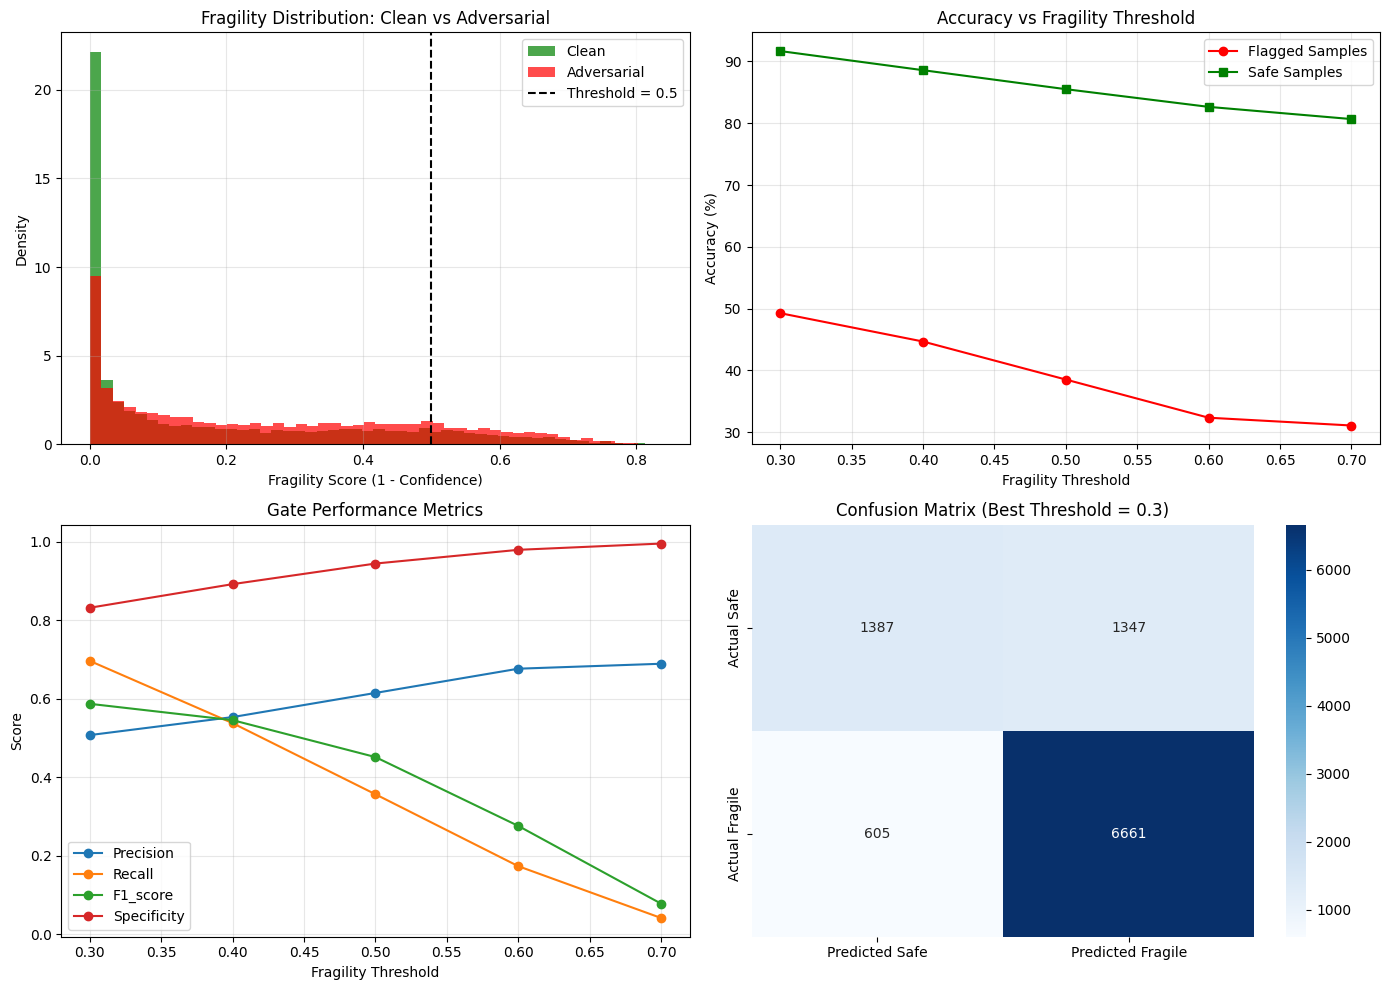

In [ ]:
# ─────────────────────────────────────────────────────────────
# --Visualization: Fragility Distribution
# ─────────────────────────────────────────────────────────────

def plot_fragility_distribution(fragility_results, gate_results, threshold=0.5):
    """Visualize fragility score distributions"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Fragility distribution comparison
    ax1 = axes[0, 0]
    ax1.hist(fragility_results['clean']['fragility'], bins=50, alpha=0.7, label='Clean', color='green', density=True)
    ax1.hist(fragility_results['adversarial']['fragility'], bins=50, alpha=0.7, label='Adversarial', color='red', density=True)
    ax1.axvline(x=threshold, color='black', linestyle='--', label=f'Threshold = {threshold}')
    ax1.set_xlabel('Fragility Score (1 - Confidence)')
    ax1.set_ylabel('Density')
    ax1.set_title('Fragility Distribution: Clean vs Adversarial')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Accuracy vs Fragility threshold
    ax2 = axes[0, 1]
    thresh_values = []
    flagged_acc = []
    safe_acc = []
    
    for thresh, results in gate_results.items():
        thresh_values.append(thresh)
        flagged_acc.append(results['gate_metrics']['flagged_accuracy'])
        safe_acc.append(results['gate_metrics']['safe_accuracy'])
    
    ax2.plot(thresh_values, flagged_acc, 'o-', label='Flagged Samples', color='red')
    ax2.plot(thresh_values, safe_acc, 's-', label='Safe Samples', color='green')
    ax2.set_xlabel('Fragility Threshold')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy vs Fragility Threshold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Gate Performance Metrics
    ax3 = axes[1, 0]
    metrics_to_plot = ['precision', 'recall', 'f1_score', 'specificity']
    for metric in metrics_to_plot:
        values = [gate_results[thresh]['gate_metrics'][metric] for thresh in thresh_values]
        ax3.plot(thresh_values, values, 'o-', label=metric.capitalize())
    ax3.set_xlabel('Fragility Threshold')
    ax3.set_ylabel('Score')
    ax3.set_title('Gate Performance Metrics')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Confusion Matrix for best threshold
    ax4 = axes[1, 1]
    best_thresh = max(gate_results.keys(), key=lambda x: gate_results[x]['gate_metrics']['f1_score'])
    cm = gate_results[best_thresh]['gate_metrics']['confusion_matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
                xticklabels=['Predicted Safe', 'Predicted Fragile'],
                yticklabels=['Actual Safe', 'Actual Fragile'])
    ax4.set_title(f'Confusion Matrix (Best Threshold = {best_thresh})')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot the results
fig = plot_fragility_distribution(fragility_results, gate_results, threshold=0.5)


In [ ]:
# ─────────────────────────────────────────────────────────────
# -- Summary Table
# ─────────────────────────────────────────────────────────────

def create_summary_table(fragility_results, gate_results):
    """Create a comprehensive summary table"""
    summary = {
        'Metric': [],
        'Value': []
    }
    
    # Clean metrics
    summary['Metric'].append('Clean Accuracy (%)')
    summary['Value'].append(f"{fragility_results['clean']['accuracy']:.2f}")
    
    summary['Metric'].append('Adversarial Accuracy (%)')
    summary['Value'].append(f"{fragility_results['adversarial']['accuracy']:.2f}")
    
    summary['Metric'].append('Accuracy Drop (%)')
    summary['Value'].append(f"{fragility_results['clean']['accuracy'] - fragility_results['adversarial']['accuracy']:.2f}")
    
    summary['Metric'].append('Clean Avg Fragility')
    summary['Value'].append(f"{np.mean(fragility_results['clean']['fragility']):.4f}")
    
    summary['Metric'].append('Adversarial Avg Fragility')
    summary['Value'].append(f"{np.mean(fragility_results['adversarial']['fragility']):.4f}")
    
    # Best gate performance
    best_thresh = max(gate_results.keys(), key=lambda x: gate_results[x]['gate_metrics']['f1_score'])
    best_metrics = gate_results[best_thresh]['gate_metrics']
    
    summary['Metric'].append('Best Fragility Threshold')
    summary['Value'].append(f"{best_thresh}")
    
    summary['Metric'].append('Best F1-Score')
    summary['Value'].append(f"{best_metrics['f1_score']:.4f}")
    
    summary['Metric'].append('Best Precision')
    summary['Value'].append(f"{best_metrics['precision']:.4f}")
    
    summary['Metric'].append('Best Recall')
    summary['Value'].append(f"{best_metrics['recall']:.4f}")
    
    summary_df = pd.DataFrame(summary)
    
    print("\n" + "=" * 60)
    print("📋 SUMMARY TABLE")
    print("=" * 60)
    print(summary_df.to_string(index=False))
    
    return summary_df

summary_df = create_summary_table(fragility_results, gate_results)

print("\n✅ Part J Complete!")


📋 SUMMARY TABLE
                   Metric  Value
       Clean Accuracy (%)  80.08
 Adversarial Accuracy (%)  40.59
        Accuracy Drop (%)  39.49
      Clean Avg Fragility 0.1768
Adversarial Avg Fragility 0.2562
 Best Fragility Threshold    0.3
            Best F1-Score 0.5870
           Best Precision 0.5073
              Best Recall 0.6963

✅ Part J Complete!



📋 EXPERIMENT SUMMARY
📅 Run Date: 2026-07-27 11:33:36
📊 Dataset: CIFAR-10
🤖 Model: Baseline CNN
⚡ Attack: FGSM (ε=0.03)

────────────────────────────────────────────────────────────
1️⃣ BASELINE MODEL PERFORMANCE
────────────────────────────────────────────────────────────

  ✅ Clean Accuracy:           80.08%
  ⚔️ Adversarial Accuracy:     40.59%
  📉 Accuracy Drop:            39.49%

  📈 Clean Confidence:         0.8232
  📉 Adversarial Confidence:   0.7438
  📊 Confidence Drop:          0.0794

  📊 Clean Fragility:          0.1768
  📊 Adversarial Fragility:    0.2562
  📈 Fragility Increase:       0.0794


────────────────────────────────────────────────────────────
2️⃣ FRAGILITY METHODS COMPARISON
────────────────────────────────────────────────────────────
            Method  Accuracy (%)  Avg Confidence  Avg Fragility  Std Fragility
    Clean Baseline         80.08        0.823249       0.176751       0.210796
Adversarial (FGSM)         40.59        0.743811       0.256189       0.21

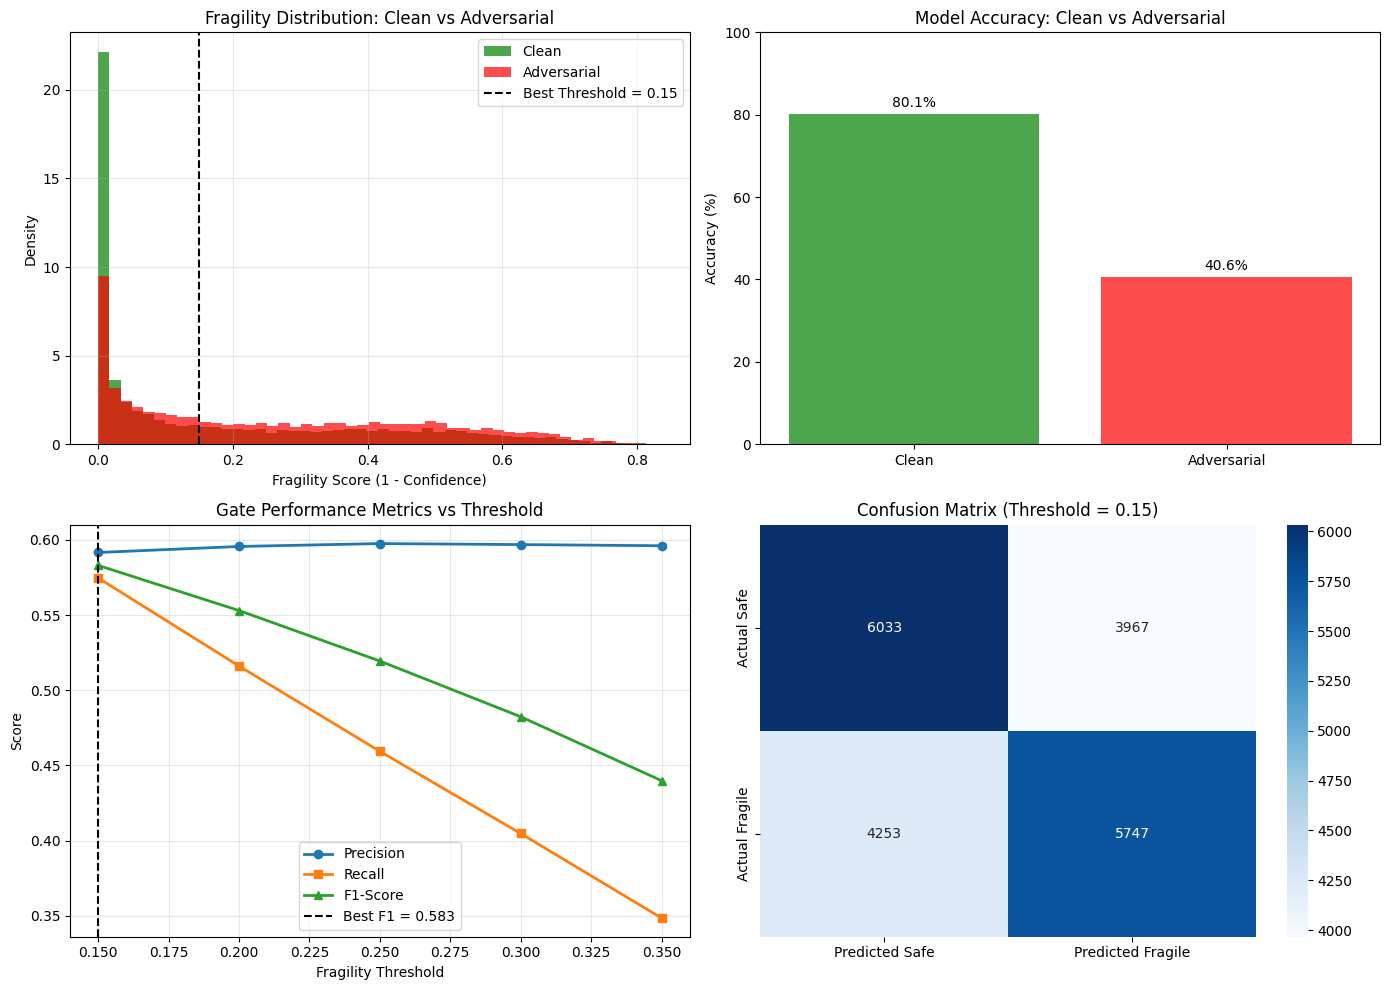


────────────────────────────────────────────────────────────
6️⃣ FINAL SUMMARY TABLE
────────────────────────────────────────────────────────────
                   Metric  Value
       Clean Accuracy (%)  80.08
 Adversarial Accuracy (%)  40.59
        Accuracy Drop (%)  39.49
      Clean Avg Fragility 0.1768
Adversarial Avg Fragility 0.2562
       Fragility Increase 0.0794
           Best Threshold   0.15
            Best F1-Score 0.5830
           Gate Precision 0.5916
              Gate Recall 0.5747
         Gate Specificity 0.6033
      Flagged Samples (%)   48.6
        Gate Coverage (%)   51.4
            Gate Risk (%)   40.8

────────────────────────────────────────────────────────────
7️⃣ SAVING RESULTS
────────────────────────────────────────────────────────────
✅ Saved fragility results to 'fragility_results.csv'
✅ Saved experiment summary to 'experiment_summary.csv'

🎯 CONCLUSION
⚠️  The model is highly vulnerable to FGSM attacks.
📊 The fragility gate shows moderate perfor

In [ ]:
# ─────────────────────────────────────────────────────────────
# Part K: Summary and Outputs 
# ─────────────────────────────────────────────────────────────

from datetime import datetime

print("\n" + "="*60)
print("📋 EXPERIMENT SUMMARY")
print("="*60)
print(f"📅 Run Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📊 Dataset: CIFAR-10")
print(f"🤖 Model: Baseline CNN")
print(f"⚡ Attack: FGSM (ε=0.03)")
print("="*60)

# ─────────────────────────────────────────────────────────────
# 1. Baseline Model Performance
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*60)
print("1️⃣ BASELINE MODEL PERFORMANCE")
print("─"*60)

# Extract values from your fragility_results
clean_acc = fragility_results['clean']['accuracy']
adv_acc = fragility_results['adversarial']['accuracy']
accuracy_drop = clean_acc - adv_acc

clean_conf = np.mean(fragility_results['clean']['confidences'])
adv_conf = np.mean(fragility_results['adversarial']['confidences'])
conf_drop = clean_conf - adv_conf

clean_frag = np.mean(fragility_results['clean']['fragility'])
adv_frag = np.mean(fragility_results['adversarial']['fragility'])
frag_increase = adv_frag - clean_frag

print(f"""
  ✅ Clean Accuracy:           {clean_acc:.2f}%
  ⚔️ Adversarial Accuracy:     {adv_acc:.2f}%
  📉 Accuracy Drop:            {accuracy_drop:.2f}%
  
  📈 Clean Confidence:         {clean_conf:.4f}
  📉 Adversarial Confidence:   {adv_conf:.4f}
  📊 Confidence Drop:          {conf_drop:.4f}
  
  📊 Clean Fragility:          {clean_frag:.4f}
  📊 Adversarial Fragility:    {adv_frag:.4f}
  📈 Fragility Increase:       {frag_increase:.4f}
""")

# ─────────────────────────────────────────────────────────────
# 2. Fragility Methods Comparison
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*60)
print("2️⃣ FRAGILITY METHODS COMPARISON")
print("─"*60)

# Create a comparison table
comparison_data = {
    'Method': ['Clean Baseline', 'Adversarial (FGSM)'],
    'Accuracy (%)': [clean_acc, adv_acc],
    'Avg Confidence': [clean_conf, adv_conf],
    'Avg Fragility': [clean_frag, adv_frag],
    'Std Fragility': [
        np.std(fragility_results['clean']['fragility']),
        np.std(fragility_results['adversarial']['fragility'])
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Additional fragility statistics
print("\n📊 Fragility Score Distribution:")
print(f"  Clean - Min: {np.min(fragility_results['clean']['fragility']):.4f}, "
      f"Max: {np.max(fragility_results['clean']['fragility']):.4f}")
print(f"  Adversarial - Min: {np.min(fragility_results['adversarial']['fragility']):.4f}, "
      f"Max: {np.max(fragility_results['adversarial']['fragility']):.4f}")

# ─────────────────────────────────────────────────────────────
# 3. Gate Performance Evaluation
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*60)
print("3️⃣ GATE PERFORMANCE WITH FRAGILITY FLAG")
print("─"*60)

# Analyze different thresholds
thresholds = [0.15, 0.20, 0.25, 0.30, 0.35]
gate_results = {}

print("\n📊 Gate Performance at Different Thresholds:")
print("-"*50)
print(f"{'Threshold':<12} {'Flagged %':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*50)

best_f1 = 0
best_threshold = 0

for thresh in thresholds:
    # Flag samples based on fragility
    clean_flags = fragility_results['clean']['fragility'] > thresh
    adv_flags = fragility_results['adversarial']['fragility'] > thresh
    
    # Calculate gate metrics
    total_clean = len(clean_flags)
    total_adv = len(adv_flags)
    
    # True positives: adversarial samples correctly flagged as fragile
    tp = np.sum(adv_flags)
    # False positives: clean samples incorrectly flagged as fragile
    fp = np.sum(clean_flags)
    # False negatives: adversarial samples NOT flagged as fragile
    fn = total_adv - tp
    # True negatives: clean samples correctly NOT flagged
    tn = total_clean - fp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    flagged_pct = (fp + tp) / (total_clean + total_adv) * 100
    
    gate_results[thresh] = {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'flagged_pct': flagged_pct,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    }
    
    print(f"{thresh:<12.2f} {flagged_pct:<12.2f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print("-"*50)
print(f"\n🏆 Best Threshold: {best_threshold} (F1-Score: {best_f1:.4f})")

# ─────────────────────────────────────────────────────────────
# 4. Optimal Gate Configuration
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*60)
print("4️⃣ OPTIMAL GATE CONFIGURATION")
print("─"*60)

best = gate_results[best_threshold]
clean_flags_best = fragility_results['clean']['fragility'] > best_threshold
adv_flags_best = fragility_results['adversarial']['fragility'] > best_threshold

print(f"""
  🎯 Threshold:                    {best_threshold}
  📊 F1-Score:                     {best['f1']:.4f}
  🎯 Precision:                    {best['precision']:.4f}
  📈 Recall:                       {best['recall']:.4f}
  🛡️ Specificity:                  {best['specificity']:.4f}
  
  📊 Flagged Samples:
     - Clean (false positives):    {best['fp']} / {len(clean_flags_best)} ({best['fp']/len(clean_flags_best)*100:.1f}%)
     - Adversarial (true positives): {best['tp']} / {len(adv_flags_best)} ({best['tp']/len(adv_flags_best)*100:.1f}%)
     - Total flagged:              {best['fp'] + best['tp']} ({best['flagged_pct']:.1f}%)
  
  ✅ Gate Coverage:                {100 - best['flagged_pct']:.1f}% (samples not flagged)
  ⚠️ Gate Risk:                    {best['fp'] / (best['fp'] + best['tp']) * 100:.1f}% (false alarm rate)
""")

# ─────────────────────────────────────────────────────────────
# 5. Visualizations
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*60)
print("5️⃣ GENERATING VISUALIZATIONS")
print("─"*60)

# Create summary plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Fragility Distribution
ax1 = axes[0, 0]
ax1.hist(fragility_results['clean']['fragility'], bins=50, alpha=0.7, 
         label='Clean', color='green', density=True)
ax1.hist(fragility_results['adversarial']['fragility'], bins=50, alpha=0.7, 
         label='Adversarial', color='red', density=True)
ax1.axvline(x=best_threshold, color='black', linestyle='--', 
            label=f'Best Threshold = {best_threshold}')
ax1.set_xlabel('Fragility Score (1 - Confidence)')
ax1.set_ylabel('Density')
ax1.set_title('Fragility Distribution: Clean vs Adversarial')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy Comparison
ax2 = axes[0, 1]
metrics = ['Clean', 'Adversarial']
accuracies = [clean_acc, adv_acc]
colors = ['green', 'red']
bars = ax2.bar(metrics, accuracies, color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Model Accuracy: Clean vs Adversarial')
ax2.set_ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}%', ha='center', va='bottom')

# Plot 3: Gate Performance vs Threshold
ax3 = axes[1, 0]
thresh_values = list(gate_results.keys())
precision_values = [gate_results[t]['precision'] for t in thresh_values]
recall_values = [gate_results[t]['recall'] for t in thresh_values]
f1_values = [gate_results[t]['f1'] for t in thresh_values]

ax3.plot(thresh_values, precision_values, 'o-', label='Precision', linewidth=2)
ax3.plot(thresh_values, recall_values, 's-', label='Recall', linewidth=2)
ax3.plot(thresh_values, f1_values, '^-', label='F1-Score', linewidth=2)
ax3.axvline(x=best_threshold, color='black', linestyle='--', 
            label=f'Best F1 = {best_f1:.3f}')
ax3.set_xlabel('Fragility Threshold')
ax3.set_ylabel('Score')
ax3.set_title('Gate Performance Metrics vs Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Confusion Matrix for Best Threshold
ax4 = axes[1, 1]
cm = np.array([[best['tn'], best['fp']], [best['fn'], best['tp']]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Predicted Safe', 'Predicted Fragile'],
            yticklabels=['Actual Safe', 'Actual Fragile'])
ax4.set_title(f'Confusion Matrix (Threshold = {best_threshold})')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 6. Final Summary Table
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*60)
print("6️⃣ FINAL SUMMARY TABLE")
print("─"*60)

summary_data = {
    'Metric': [
        'Clean Accuracy (%)',
        'Adversarial Accuracy (%)',
        'Accuracy Drop (%)',
        'Clean Avg Fragility',
        'Adversarial Avg Fragility',
        'Fragility Increase',
        'Best Threshold',
        'Best F1-Score',
        'Gate Precision',
        'Gate Recall',
        'Gate Specificity',
        'Flagged Samples (%)',
        'Gate Coverage (%)',
        'Gate Risk (%)'
    ],
    'Value': [
        f'{clean_acc:.2f}',
        f'{adv_acc:.2f}',
        f'{accuracy_drop:.2f}',
        f'{clean_frag:.4f}',
        f'{adv_frag:.4f}',
        f'{frag_increase:.4f}',
        f'{best_threshold:.2f}',
        f'{best_f1:.4f}',
        f'{best["precision"]:.4f}',
        f'{best["recall"]:.4f}',
        f'{best["specificity"]:.4f}',
        f'{best["flagged_pct"]:.1f}',
        f'{100 - best["flagged_pct"]:.1f}',
        f'{best["fp"] / (best["fp"] + best["tp"]) * 100:.1f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────
# 7. Save Results to CSV
# ─────────────────────────────────────────────────────────────

print("\n" + "─"*60)
print("7️⃣ SAVING RESULTS")
print("─"*60)

# Save fragility scores
clean_df = pd.DataFrame({
    'label': fragility_results['clean']['labels'],
    'prediction': fragility_results['clean']['predictions'],
    'confidence': fragility_results['clean']['confidences'],
    'fragility': fragility_results['clean']['fragility'],
    'type': 'clean'
})

adv_df = pd.DataFrame({
    'label': fragility_results['adversarial']['labels'],
    'prediction': fragility_results['adversarial']['predictions'],
    'confidence': fragility_results['adversarial']['confidences'],
    'fragility': fragility_results['adversarial']['fragility'],
    'type': 'adversarial'
})

all_results = pd.concat([clean_df, adv_df], ignore_index=True)
all_results.to_csv('fragility_results.csv', index=False)
print("✅ Saved fragility results to 'fragility_results.csv'")

# Save summary
summary_df.to_csv('experiment_summary.csv', index=False)
print("✅ Saved experiment summary to 'experiment_summary.csv'")

# ─────────────────────────────────────────────────────────────
# 8. Conclusion
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("🎯 CONCLUSION")
print("="*60)

if accuracy_drop > 30:
    print("⚠️  The model is highly vulnerable to FGSM attacks.")
elif accuracy_drop > 15:
    print("⚡ The model shows moderate vulnerability to FGSM attacks.")
else:
    print("✅ The model is relatively robust to FGSM attacks.")

if best_f1 > 0.7:
    print("✅ The fragility gate shows strong performance.")
elif best_f1 > 0.5:
    print("📊 The fragility gate shows moderate performance.")
else:
    print("⚠️  The fragility gate shows weak performance.")

print(f"""
📌 Key Findings:
  1. FGSM attack (ε=0.03) reduced accuracy by {accuracy_drop:.1f}%
  2. Fragility increased by {frag_increase:.4f} on adversarial samples
  3. Optimal gate threshold: {best_threshold}
  4. Gate F1-Score: {best_f1:.3f}
  5. Gate coverage: {100 - best['flagged_pct']:.1f}% of samples are safe

💡 Recommendations:
  - Consider adversarial training to improve robustness
  - Use the fragility gate to filter high-risk samples
  - Deploy the model with the gate threshold {best_threshold}
""")

print("\n" + "="*60)
print("✅ Notebook complete!")
print("="*60)